# Sample Data: MM-Food-100K --> 5K

In [ ]:
# Parameters
SAVE_DFS = False

In [2]:
import json
import os
import pandas as pd
import requests

from IPython.display import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

## Load, Preview, and Clean Data 

In [3]:
csv_file = '../data/MM-Food-100K.csv'

if SAVE_DFS:
    # Load data from Hugging Face
    df = pd.read_csv("hf://datasets/Codatta/MM-Food-100K/MM-Food-100K.csv")
    # Save to CSV
    df.to_csv(csv_file, index=False)

# Load data from previously saved CSV
df = pd.read_csv(csv_file)

/opt/anaconda3/envs/csml-proj/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df.head()

,image_url,camera_or_phone_prob,food_prob,dish_name,food_type,ingredients,portion_size,nutritional_profile,cooking_method,sub_dt
0,https://file.b18a.io/7843322356500104680_44354...,0.7,0.95,Fried Chicken,Restaurant food,"[""chicken"",""breading"",""oil""]","[""chicken:300g""]","{""fat_g"":25.0,""protein_g"":30.0,""calories_kcal""...",Frying,20250704
1,https://file.b18a.io/7833227147700100732_67487...,0.7,1.00,Pho,Restaurant food,"[""noodles"",""beef"",""basil"",""lime"",""green onions...","[""noodles:200g"",""beef:100g"",""vegetables:50g""]","{""fat_g"":15.0,""protein_g"":25.0,""calories_kcal""...",boiled,20250702
2,https://file.b18a.io/7832600581600103585_26423...,0.8,0.95,Pan-fried Dumplings,Restaurant food,"[""dumplings"",""chili oil"",""soy sauce""]","[""dumplings:300g"",""sauce:50g""]","{""fat_g"":15.0,""protein_g"":20.0,""calories_kcal""...",Pan-frying,20250625
3,https://file.b18a.io/7839056601700101188_98515...,0.7,1.00,Bananas,Raw vegetables and fruits,"[""Bananas""]","[""Bananas: 10 pieces (about 1kg)""]","{""fat_g"":3.0,""protein_g"":12.0,""calories_kcal"":...",Raw,20250718
4,https://file.b18a.io/7837642737500100261_17312...,0.8,0.90,Noodle Stir-Fry,Restaurant food,"[""noodles"",""chicken"",""vegetables"",""sauce""]","[""noodles:300g"",""chicken:100g"",""vegetables:50g""]","{""fat_g"":20.0,""protein_g"":25.0,""calories_kcal""...",stir-fried,20250711


In [5]:
# Add image name col
df['image_name'] = df['image_url'].apply(lambda x: x.split('/')[-1])
df['image_name']

0        7843322356500104680_443548_.jpeg
1        7833227147700100732_674878_.jpeg
2         7832600581600103585_264234_.jpg
3         7839056601700101188_985151_.jpg
4        7837642737500100261_173129_.jpeg
                       ...               
99995    7833255010300109931_288881_.jpeg
99996     7837300073200100128_713146_.jpg
99997    7832710876500109045_733930_.jpeg
99998    7839064030900102356_782681_.jpeg
99999     7832697331600109060_992251_.jpg
Name: image_name, Length: 100000, dtype: object

In [6]:
df['camera_or_phone_prob'].value_counts()

camera_or_phone_prob
0.70    51629
0.80    47879
0.90      200
0.85      161
0.60      131
Name: count, dtype: int64

In [7]:
df['food_prob'].value_counts()

food_prob
0.90    54627
1.00    32685
0.95    11870
0.80      817
0.99        1
Name: count, dtype: int64

In [8]:
df['dish_name'].value_counts()

dish_name
Noodle Soup                    1960
Dumplings                      1236
Hot Pot                         995
Stir-fried Noodles              796
Fried Chicken                   712
                               ... 
Pork Belly with Greens            1
Steamed Fish or Meat              1
Noodle Soup with Side Salad       1
Quail Egg Meat                    1
Fruit Powder                      1
Name: count, Length: 19288, dtype: int64

In [9]:
# Clean dish names (lower case)
df['dish_name'] = df['dish_name'].str.lower()
df['dish_name'].value_counts()

dish_name
noodle soup                               1960
dumplings                                 1236
hot pot                                    995
stir-fried noodles                         817
fried chicken                              712
                                          ... 
apple crepes                                 1
mixed rice with egg                          1
grilled shrimp with pineapple                1
fish and meat with vegetables and rice       1
fruit powder                                 1
Name: count, Length: 18792, dtype: int64

In [10]:
# We'll do a stratified split based on this column
df['food_type'] = df['food_type'].str.lower()
df['food_type'].value_counts()

food_type
homemade food                46555
restaurant food              35461
raw vegetables and fruits     9357
packaged food                 8354
others                         273
Name: count, dtype: int64

In [11]:
df['ingredients']

0                             ["chicken","breading","oil"]
1        ["noodles","beef","basil","lime","green onions...
2                    ["dumplings","chili oil","soy sauce"]
3                                              ["Bananas"]
4               ["noodles","chicken","vegetables","sauce"]
                               ...                        
99995       ["crawfish","green peppers","onions","spices"]
99996                   ["chicken wings","breading","oil"]
99997    ["steak","fries","broccoli","carrots","bell pe...
99998                                       ["tofu","oil"]
99999    ["green peppers","ground meat","soy sauce","ga...
Name: ingredients, Length: 100000, dtype: object

In [12]:
# Clean ingredients (lower case)
df['ingredients'] = df['ingredients'].apply(lambda x: 
                                            [item.lower() 
                                             for item in json.loads(x)])
df['ingredients']

0                                 [chicken, breading, oil]
1        [noodles, beef, basil, lime, green onions, chili]
2                        [dumplings, chili oil, soy sauce]
3                                                [bananas]
4                    [noodles, chicken, vegetables, sauce]
                               ...                        
99995            [crawfish, green peppers, onions, spices]
99996                       [chicken wings, breading, oil]
99997    [steak, fries, broccoli, carrots, bell peppers...
99998                                          [tofu, oil]
99999      [green peppers, ground meat, soy sauce, garlic]
Name: ingredients, Length: 100000, dtype: object

In [13]:
df['portion_size']

0                                        ["chicken:300g"]
1           ["noodles:200g","beef:100g","vegetables:50g"]
2                          ["dumplings:300g","sauce:50g"]
3                      ["Bananas: 10 pieces (about 1kg)"]
4        ["noodles:300g","chicken:100g","vegetables:50g"]
                               ...                       
99995                 ["crawfish:500g","vegetables:100g"]
99996                              ["chicken wings:300g"]
99997       ["steak:250g","fries:150g","vegetables:100g"]
99998                                       ["tofu:300g"]
99999           ["green_peppers:300g","ground_meat:100g"]
Name: portion_size, Length: 100000, dtype: object

In [14]:
# Clean portion sizes (lower case, turn into dicts)
df['portion_size'] = df['portion_size'].apply(lambda x: 
                                              {item.split(':')[0].lower(): item.split(':')[1] 
                                               for item in json.loads(x)})
df['portion_size']

0                                      {'chicken': '300g'}
1        {'noodles': '200g', 'beef': '100g', 'vegetable...
2                    {'dumplings': '300g', 'sauce': '50g'}
3                    {'bananas': ' 10 pieces (about 1kg)'}
4        {'noodles': '300g', 'chicken': '100g', 'vegeta...
                               ...                        
99995           {'crawfish': '500g', 'vegetables': '100g'}
99996                            {'chicken wings': '300g'}
99997    {'steak': '250g', 'fries': '150g', 'vegetables...
99998                                     {'tofu': '300g'}
99999     {'green_peppers': '300g', 'ground_meat': '100g'}
Name: portion_size, Length: 100000, dtype: object

In [15]:
# Fix portion size with invalid key ('100g': '100g')
print(df.loc[df['image_name'] == '7837758435800103286_974448_.jpg', 'portion_size'])
df.loc[df['image_name'] == '7837758435800103286_974448_.jpg', 'portion_size'] = "{'fish': '100g'}"
df.loc[df['image_name'] == '7837758435800103286_974448_.jpg']

81834    {'100g': '100g'}
Name: portion_size, dtype: object


,image_url,camera_or_phone_prob,food_prob,dish_name,food_type,ingredients,portion_size,nutritional_profile,cooking_method,sub_dt,image_name
81834,https://file.b18a.io/7837758435800103286_97444...,0.7,0.9,spicy fish snack,packaged food,"[fish, spices, oil]",{'fish': '100g'},"{""fat_g"":18.6,""protein_g"":31.9,""calories_kcal""...",Packaged,20250705,7837758435800103286_974448_.jpg


In [16]:
df['nutritional_profile']

0        {"fat_g":25.0,"protein_g":30.0,"calories_kcal"...
1        {"fat_g":15.0,"protein_g":25.0,"calories_kcal"...
2        {"fat_g":15.0,"protein_g":20.0,"calories_kcal"...
3        {"fat_g":3.0,"protein_g":12.0,"calories_kcal":...
4        {"fat_g":20.0,"protein_g":25.0,"calories_kcal"...
                               ...                        
99995    {"fat_g":20.0,"protein_g":40.0,"calories_kcal"...
99996    {"fat_g":25.0,"protein_g":20.0,"calories_kcal"...
99997    {"fat_g":45.0,"protein_g":60.0,"calories_kcal"...
99998    {"fat_g":12.0,"protein_g":20.0,"calories_kcal"...
99999    {"fat_g":20.0,"protein_g":25.0,"calories_kcal"...
Name: nutritional_profile, Length: 100000, dtype: object

In [17]:
# Clean nutritional profiles (turn into dicts)
df['nutritional_profile'] = df['nutritional_profile'].apply(lambda x: json.loads(x))
df['nutritional_profile']

0        {'fat_g': 25.0, 'protein_g': 30.0, 'calories_k...
1        {'fat_g': 15.0, 'protein_g': 25.0, 'calories_k...
2        {'fat_g': 15.0, 'protein_g': 20.0, 'calories_k...
3        {'fat_g': 3.0, 'protein_g': 12.0, 'calories_kc...
4        {'fat_g': 20.0, 'protein_g': 25.0, 'calories_k...
                               ...                        
99995    {'fat_g': 20.0, 'protein_g': 40.0, 'calories_k...
99996    {'fat_g': 25.0, 'protein_g': 20.0, 'calories_k...
99997    {'fat_g': 45.0, 'protein_g': 60.0, 'calories_k...
99998    {'fat_g': 12.0, 'protein_g': 20.0, 'calories_k...
99999    {'fat_g': 20.0, 'protein_g': 25.0, 'calories_k...
Name: nutritional_profile, Length: 100000, dtype: object

In [18]:
df['cooking_method'].value_counts()

cooking_method
Raw                                           11598
boiling                                        7162
Fried                                          6286
Stir-frying                                    5887
stir-frying                                    5325
                                              ...  
Packaged, ready to mix                            1
Beverage preparation and baking                   1
Grilled or Fried                                  1
No cooking, prepared by soaking chia seeds        1
microwave or boiling                              1
Name: count, Length: 2264, dtype: int64

In [19]:
# Clean cooking methods (lower case)
df['cooking_method'] = df['cooking_method'].str.lower()
df['cooking_method'].value_counts()

cooking_method
raw                           11732
stir-frying                   11212
boiling                        7314
fried                          6430
baked                          4445
                              ...  
raw/served for grilling           1
none (packaged and raw)           1
stewed and layered cooking        1
steaming and simmering            1
microwave or boiling              1
Name: count, Length: 1824, dtype: int64

In [20]:
csv_file = '../data/MM-Food-100K-cleaned.csv'

if SAVE_DFS:
    # Save to CSV
    df.to_csv(csv_file, index=False)
    
# Load data from previously saved CSV
df = pd.read_csv(csv_file)

## Train/Val/Test Split

- 80/10/10 split

In [21]:
stratify_cols = ["food_type"]
# Train/Test split
df_train, df_test = train_test_split(df, test_size=0.1, stratify=df[stratify_cols], random_state=42)
# Train/Val split
df_train, df_val = train_test_split(df_train, test_size=0.1/0.9, stratify=df_train[stratify_cols], random_state=42)
print(f'{df_train.shape=}, {df_val.shape=}, {df_test.shape=}')

df_train.shape=(80000, 11), df_val.shape=(10000, 11), df_test.shape=(10000, 11)


## Sample Data per Split

In [22]:
# Sample Train
df_train, _ = train_test_split(df_train, train_size=0.05, stratify=df_train[stratify_cols], random_state=42)
print(f'{df_train.shape=}')
# Sample Val
df_val, _ = train_test_split(df_val, train_size=0.05, stratify=df_val[stratify_cols], random_state=42)
print(f'{df_val.shape=}')
# Sample Test
df_test, _ = train_test_split(df_test, train_size=0.05, stratify=df_test[stratify_cols], random_state=42)
print(f'{df_test.shape=}')

df_train.shape=(4000, 11)
df_val.shape=(500, 11)
df_test.shape=(500, 11)


In [23]:
if SAVE_DFS:
    # Save splits to CSVs
    df_train.to_csv('../data/train/df_train.csv', index=False)
    df_val.to_csv('../data/val/df_val.csv', index=False)
    df_test.to_csv('../data/test/df_test.csv', index=False)

In [24]:
# Load splits from CSVs
df_train = pd.read_csv('../data/train/df_train.csv')
df_val = pd.read_csv('../data/val/df_val.csv')
df_test = pd.read_csv('../data/test/df_test.csv')

df_train.head(2)

,image_url,camera_or_phone_prob,food_prob,dish_name,food_type,ingredients,portion_size,nutritional_profile,cooking_method,sub_dt,image_name
0,https://file.b18a.io/7832973280900104501_54585...,0.8,0.90,oysters,homemade food,['oysters'],{'oysters': '500g'},"{'fat_g': 5.0, 'protein_g': 20.0, 'calories_kc...",raw,20250710,7832973280900104501_545859_.jpeg
1,https://file.b18a.io/7835136777400102715_70587...,0.7,0.95,grilled steak,restaurant food,"['steak', 'broccoli', 'potato', 'tomato', 'sau...","{'steak': '250g', 'broccoli': '50g', 'potato':...","{'fat_g': 30.0, 'protein_g': 50.0, 'calories_k...",grilling,20250702,7835136777400102715_705873_.jpeg


In [25]:
df_train['food_type'].value_counts()

food_type
homemade food                1862
restaurant food              1419
raw vegetables and fruits     374
packaged food                 334
others                         11
Name: count, dtype: int64

In [26]:
df_val['food_type'].value_counts()

food_type
homemade food                233
restaurant food              177
raw vegetables and fruits     47
packaged food                 42
others                         1
Name: count, dtype: int64

In [27]:
df_test['food_type'].value_counts()

food_type
homemade food                233
restaurant food              177
raw vegetables and fruits     47
packaged food                 42
others                         1
Name: count, dtype: int64

## Download Images per Split

In [28]:
def download_image(image_path, save_dir='../data/download-trial/'):
    image_name = image_path.split('/')[-1]
    save_path = save_dir + image_name
    if not os.path.isfile(save_path):
        # print(f'Downloading {image_name} to {save_dir}')
        img_data = requests.get(image_path).content
        with open(save_path, 'wb') as handler:
            handler.write(img_data)
    # else:
        # print(f'{image_name} already exists in {save_dir}')

https://file.b18a.io/7833227147700100732_674878_.jpeg


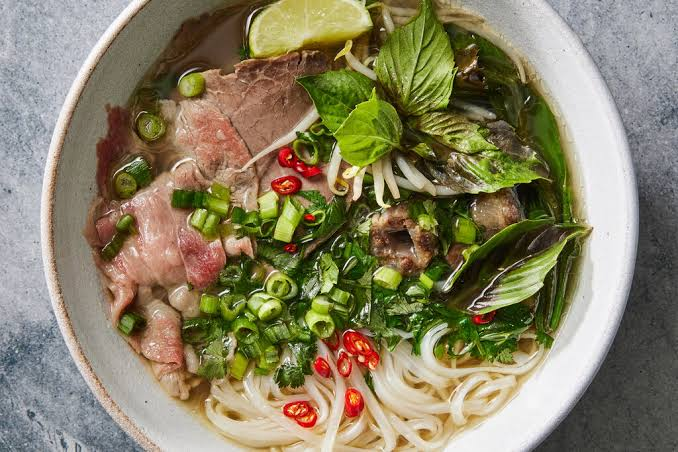

In [29]:
image_path = df['image_url'][1]
download_image(image_path)
print(image_path)
Image(image_path)

In [30]:
# Train
save_dir='../data/train/'
for row in tqdm(df_train.itertuples(), total=len(df_train)):
    row.image_url
    download_image(row.image_url, save_dir)

dir = '../data/train'
print(len([name for name in os.listdir(dir) if os.path.isfile(os.path.join(dir, name))]))

100%|██████████| 4000/4000 [00:00<00:00, 269158.96it/s]

4001


In [31]:
# Val
save_dir='../data/val/'
for row in tqdm(df_val.itertuples(), total=len(df_val)):
    row.image_url
    download_image(row.image_url, save_dir)

dir = '../data/val'
print(len([name for name in os.listdir(dir) if os.path.isfile(os.path.join(dir, name))]))

100%|██████████| 500/500 [00:00<00:00, 220173.44it/s]

501


In [32]:
# Test
save_dir='../data/test/'
for row in tqdm(df_test.itertuples(), total=len(df_test)):
    row.image_url
    download_image(row.image_url, save_dir)

dir = '../data/test'
print(len([name for name in os.listdir(dir) if os.path.isfile(os.path.join(dir, name))]))

100%|██████████| 500/500 [00:00<00:00, 48803.89it/s]

501
